# `13 — Floyd–Warshall algorithm (all-pairs shortest paths)`

## **When to use**
- Need distances between **every pair** of vertices.
- Works with negative edges, but **no negative cycles** (if $d[v][v]$ becomes negative $\rightarrow$ cycle).

## **Complexity**
| Output | Time | Memory |
|---|---:|---:|
| All-pairs distances | **O(V³)** | **O(V²)** |

## **3D DP definition**
Let:
$$d^k[v][u] = \text{shortest path } v \rightarrow u$$
where internal vertices are allowed only from $\{0,1,\ldots,k\}$.

Recurrence:
$$d^k[v][u] = \min\left( d^{k-1}[v][u],  d^{k-1}[v][k] + d^{k-1}[k][u] \right)$$

Base $(k = -1)$:
$d^{-1}$ is basically the adjacency matrix (0 on diagonal, $w(v,u)$ if edge else $\infty$).

## **Why we can overwrite in 2D (no need to store k dimension)**
During iteration $k$, we update:
$$d[v][u] = \min(d[v][u], d[v][k] + d[k][u])$$

**Key fact**:
On the $k$-th iteration, the values $d[v][k]$ and $d[k][u]$ that we use
DO NOT change "in a harmful way" inside that same iteration, because:
- $d^k[v][k] = d^{k-1}[v][k]$
- $d^k[k][u] = d^{k-1}[k][u]$

So the right-hand side effectively uses the previous-$k$ values, and we can update in-place.

In [9]:
import math
import matplotlib.pyplot as plt
from typing import List, Tuple

INF = 10**9

def show_matrix(d: List[List[float]], *, title: str) -> None:
    plt.figure(figsize=(8, 8))
    plt.imshow(d, aspect="auto")
    plt.colorbar(label="distance")
    plt.title(title)
    plt.xlabel("u")
    plt.ylabel("v")
    plt.show()

def floyd_warshall_visual(a: List[List[float]], *, verbose: bool = True, plot_each_k: bool = True) -> List[List[float]]:
    n: int = len(a)
    d: List[List[float]] = [row.copy() for row in a]  # start from adjacency matrix

    if plot_each_k:
        show_matrix(d, title="Initial matrix d (k = -1 base)")

    for k in range(n):
        if verbose:
            print("-" * 70)
            print(f"Iteration k={k}: allow vertex {k} as intermediate")
            print("-" * 70)

        for v in range(n):
            for u in range(n):
                # in-place update
                cand = d[v][k] + d[k][u]
                if cand < d[v][u]:
                    if verbose and n <= 6:
                        print(f"update d[{v}][{u}]: {d[v][u]} -> {cand}  via {v}->{k}->{u}")
                    d[v][u] = cand

        if plot_each_k:
            show_matrix(d, title=f"After k={k} (intermediate vertices in [0..{k}])")

    return d



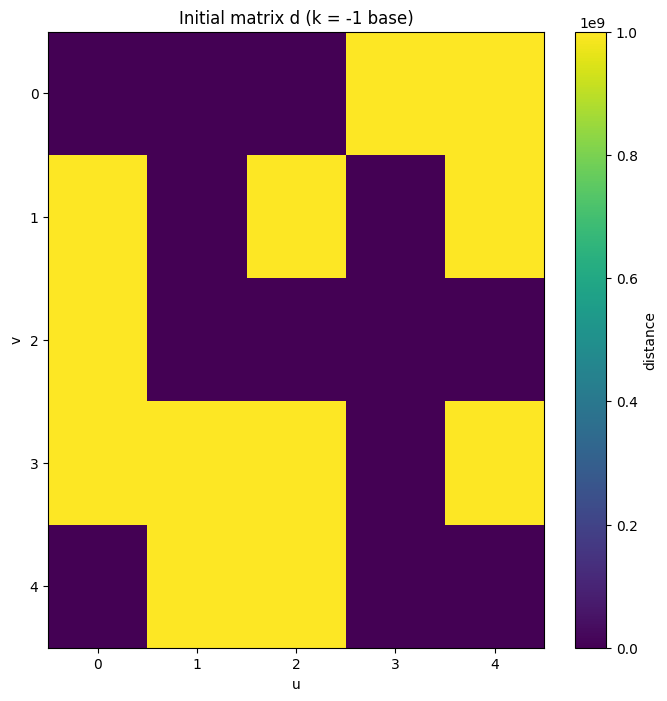

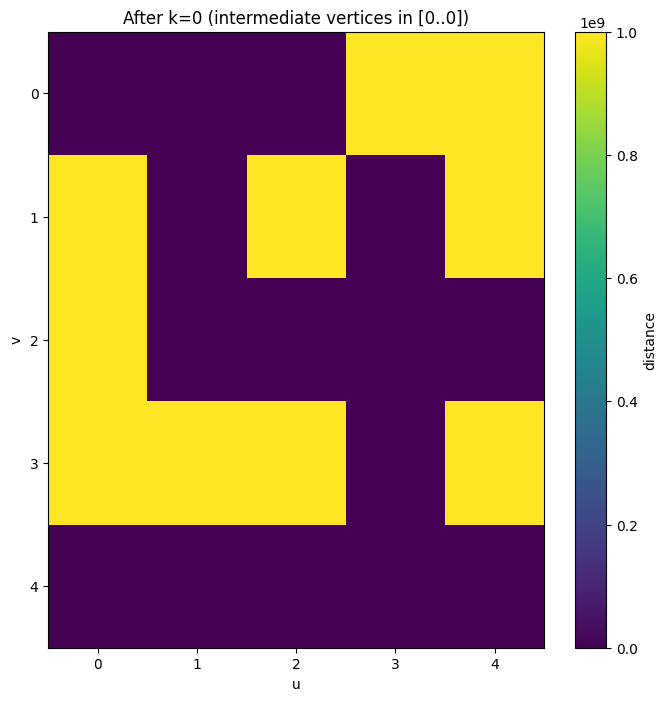

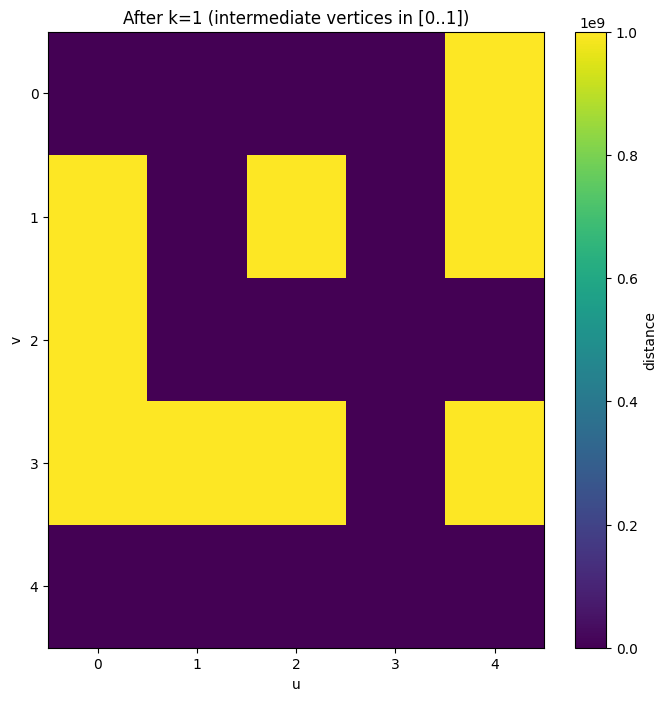

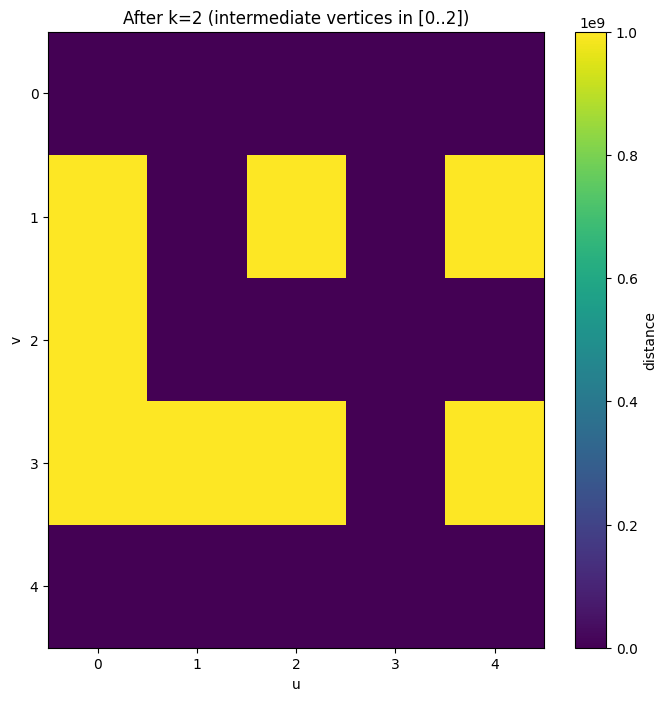

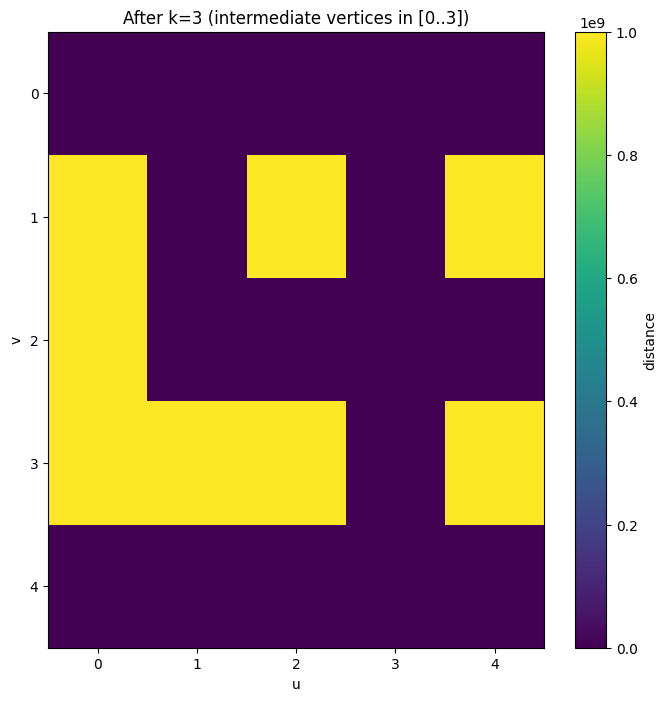

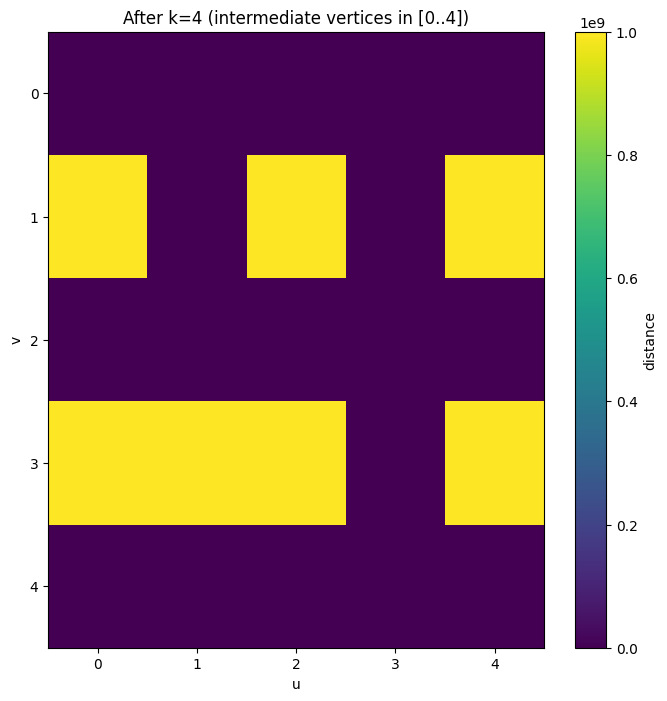

Final distance matrix:
[0, 7, 5, 8, 7]
[1000000000, 0, 1000000000, 1, 1000000000]
[9, 2, 0, 3, 2]
[1000000000, 1000000000, 1000000000, 0, 1000000000]
[7, 14, 12, 4, 0]

Negative cycle? False


In [10]:

def make_adjacency_matrix(n: int, edges: List[Tuple[int,int,float]]) -> List[List[float]]:
    a: List[List[float]] = [[INF] * n for _ in range(n)]
    for i in range(n):
        a[i][i] = 0
    for v, u, w in edges:
        a[v][u] = min(a[v][u], w)
    return a

n = 5
edges_fw = [
    (0, 1, 10),
    (0, 2, 5),
    (2, 1, 2),
    (1, 3, 1),
    (2, 3, 9),
    (2, 4, 2),
    (4, 0, 7),
    (4, 3, 4),
]

a = make_adjacency_matrix(n, edges_fw)
d = floyd_warshall_visual(a, verbose=False, plot_each_k=True)

print("Final distance matrix:")
for row in d:
    print(row)

# Negative cycle check: if any d[v][v] < 0
neg_cycle = any(d[i][i] < 0 for i in range(n))
print("\nNegative cycle?", neg_cycle)